# Power-Flow Validation: Synthetic vs Real Grids (Status Quo)

Grid-model validation of the joint SWF + ÜZW run (`joint_setup.RUN_ID`): the status-quo power flow of the
synthetic pylovo grids against the real DSO grids over the same buildings. The paper figure and table pool both
providers as *Real* and *Synthetic*, so no DSO is named; the per-provider views are diagnostics only.

**Grid set.** A grid with non-converged power-flow hours in at least 1 % of the hours of any case is left out of
every case of its own group (`joint_setup.MIN_FAILED_SHARE`): its summaries would miss exactly its worst hours.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from gridexpand.analysis.expansion.notebook_workflow import PROVIDER_LABELS, load_powerflow_cutoff_comparison
from gridexpand.analysis.plotting.powerflow_asset_plots import (
    plot_cable_max_loading_ecdf,
    plot_powerflow_asset_cutoff_overview_static,
)
from gridexpand.analysis.powerflow.comparison_data import powerflow_distribution_similarity_summary
from joint_setup import (
    CASE_COLORS,
    CASE_DISPLAY,
    CURVE_Y_LIMITS,
    NETWORK_COLORS,
    OUTPUT_DIR,
    STAGE_LABELS,
    prepare_joint_analysis,
    stage_specs,
)

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 180)

context = prepare_joint_analysis()
PRE = STAGE_LABELS["pre"]
FIGURE_DIR = OUTPUT_DIR / "powerflow"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

## Readiness

The gate checks the raw run: `compact power-flow runs complete` fails as long as any grid has non-converged hours,
also the grids excluded below.

In [2]:
display(context["powerflow_status"])
display(context["publication_gate"])
if not context["publication_ready"]:
    print("DIAGNOSTIC: at least one readiness check failed (see the gate above).")

,data_source,stage,run_name,expected_grids,launched_grids,summary_grids,pending_or_missing_summaries,grids_with_failed_timesteps,failed_timesteps,timestep_signatures,scenario_labels,profile_contracts,complete
0,Real SWF,status-quo,joint_2045_v1_full_year_swf_real_swf_pre,49,49,49,0,1,673,8760,joint_2045_v1_full_year_swf_post-hems-heuristic,physical_building_component_paired_v2,False
1,Real SWF,INFLEX,joint_2045_v1_full_year_swf_real_swf_post-infl...,49,48,48,0,10,9746,8760,joint_2045_v1_full_year_swf_post-hems-heuristic,physical_building_component_paired_v2,False
2,Real SWF,HEMS,joint_2045_v1_full_year_swf_real_swf_post-hems...,49,48,48,0,10,8728,8760,joint_2045_v1_full_year_swf_post-hems-heuristic,physical_building_component_paired_v2,False
3,Synthetic SWF,status-quo,joint_2045_v1_full_year_swf_synthetic_pre,52,52,52,0,0,0,8760,joint_2045_v1_full_year_swf_post-hems-heuristic,physical_building_component_paired_v2,True
4,Synthetic SWF,INFLEX,joint_2045_v1_full_year_swf_synthetic_post-inf...,52,52,52,0,3,6,8760,joint_2045_v1_full_year_swf_post-hems-heuristic,physical_building_component_paired_v2,False
5,Synthetic SWF,HEMS,joint_2045_v1_full_year_swf_synthetic_post-hem...,52,52,52,0,2,9,8760,joint_2045_v1_full_year_swf_post-hems-heuristic,physical_building_component_paired_v2,False
6,Real ÜZW,status-quo,joint_2045_v1_full_year_uzw_real_uzw_pre,213,213,213,0,0,0,8760,joint_2045_v1_full_year_uzw_post-hems-heuristic,physical_building_component_paired_v2,True
7,Real ÜZW,INFLEX,joint_2045_v1_full_year_uzw_real_uzw_post-infl...,213,213,213,0,1,35,8760,joint_2045_v1_full_year_uzw_post-hems-heuristic,physical_building_component_paired_v2,False
8,Real ÜZW,HEMS,joint_2045_v1_full_year_uzw_real_uzw_post-hems...,213,213,213,0,1,34,8760,joint_2045_v1_full_year_uzw_post-hems-heuristic,physical_building_component_paired_v2,False
9,Synthetic ÜZW,status-quo,joint_2045_v1_full_year_uzw_synthetic_pre,230,230,230,0,0,0,8760,joint_2045_v1_full_year_uzw_post-hems-heuristic,physical_building_component_paired_v2,True


,check,passed,detail
0,All 12 compact power-flow runs complete,False,1630 grid-stage summaries; 19231 failed timesteps
1,Shared temporal horizon,True,8760
2,Scenario labels of this run,True,joint_2045_v1_full_year_swf_post-hems-heuristi...
3,Single paired profile contract,True,physical_building_component_paired_v2
4,12 matching synthetic/real expansion materiali...,False,0/12 available
5,All materialized grid costs complete,False,0 incomplete and 0 explicitly excluded grid-st...


DIAGNOSTIC: at least one readiness check failed (see the gate above).


## Non-converged grids

Every grid with non-converged hours in one of the cases. `excluded` marks the grids left out; the others stay in,
their few missing hours barely move the summaries.

In [3]:
display(context["nonconverged"])
context["excluded_grids"]

,data_source,network,provider,grid,grid_key,cases,max_failed_timesteps,n_timesteps,max_failed_share,excluded
0,Real SWF,Real,SWF,SWF LV_113,113,"status-quo, INFLEX, HEMS",4183,8760,0.477511,True
1,Real SWF,Real,SWF,SWF LV_059,59,"INFLEX, HEMS",2140,8760,0.244292,True
2,Real SWF,Real,SWF,SWF LV_038,38,"INFLEX, HEMS",1961,8760,0.223858,True
3,Real SWF,Real,SWF,SWF LV_080,80,"INFLEX, HEMS",730,8760,0.083333,True
4,Real SWF,Real,SWF,SWF LV_153,153,"INFLEX, HEMS",369,8760,0.042123,True
5,Real SWF,Real,SWF,SWF LV_034,34,"INFLEX, HEMS",147,8760,0.016781,True
6,Real SWF,Real,SWF,SWF LV_073,73,"INFLEX, HEMS",130,8760,0.014840,True
7,Real SWF,Real,SWF,SWF LV_054,54,"INFLEX, HEMS",74,8760,0.008447,False
8,Real ÜZW,Real,ÜZW,ÜZW area-0000,0,"INFLEX, HEMS",35,8760,0.003995,False
9,Real SWF,Real,SWF,SWF LV_079,79,"INFLEX, HEMS",10,8760,0.001142,False


{'Real SWF': ('113', '153', '34', '38', '59', '73', '80')}

In [4]:
comparison = load_powerflow_cutoff_comparison(
    specs_by_source=stage_specs(context, PRE),
    stage_order=[PRE],
    excluded_grids=context["excluded_grids"],
)
profile = comparison["profile"]
display(comparison["coverage_summary"])
display(comparison["excluded_grids"])

,data_source,comparison_stage,grids
0,Real SWF,status-quo,42
1,Real ÜZW,status-quo,213
2,Synthetic SWF,status-quo,52
3,Synthetic ÜZW,status-quo,230


,data_source,comparison_stage,excluded_grids,grids
0,Real SWF,status-quo,7,"SWF LV_034, SWF LV_038, SWF LV_059, SWF LV_073..."


## Distribution similarity

Synthetic minus real for the critical value of each grid asset (transformer and cable annual maximum loading,
annual minimum voltage); the pooled rows are the paper table *powerflow-distribution-summary*.

In [5]:
def similarity(frame):
    return powerflow_distribution_similarity_summary(
        frame, group_col="network", synthetic_group="Synthetic", real_group="Real"
    )


tables = {"Pooled": similarity(profile)}
for provider in context["providers"]:
    label = PROVIDER_LABELS[provider]
    tables[label] = similarity(profile[profile["provider"] == label])
similarity_table = pd.concat(tables, names=["scope"]).reset_index(level=0)
similarity_table.to_csv(FIGURE_DIR / "powerflow_distribution_similarity.csv", index=False)
similarity_table

,scope,metric,median_diff,std,wasserstein
0,Pooled,Transformer,4.006030,-4.188588,4.544558
1,Pooled,Cables,1.011109,2.079856,3.025399
2,Pooled,Voltage,-0.006369,-0.002397,0.005421
0,SWF,Transformer,3.687404,-9.568484,8.515894
1,SWF,Cables,1.143092,-0.093255,3.173088
2,SWF,Voltage,-0.004621,-0.010495,0.005611
0,ÜZW,Transformer,3.034192,-2.857979,3.832462
1,ÜZW,Cables,0.941744,3.527646,2.934108
2,ÜZW,Voltage,-0.005808,0.002208,0.005150


## Paper figure: status-quo stress

Figure *powerflow-asset-percentiles*: mean over the retained grids by retained-grid cutoff (top) and the
distribution of each grid's critical asset at the P95 cutoff (bottom), pooled Real vs Synthetic.

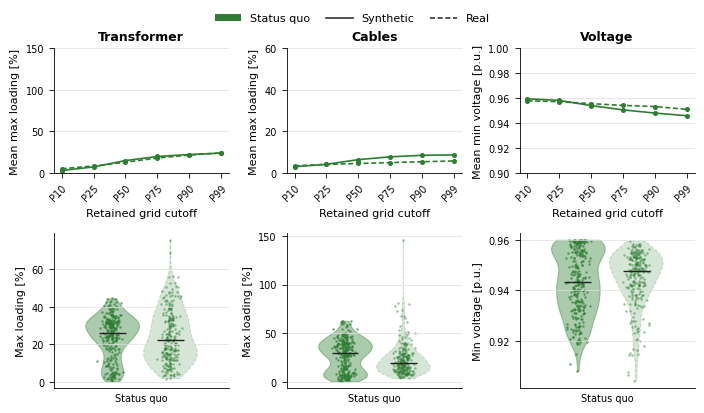

In [6]:
fig = plot_powerflow_asset_cutoff_overview_static(
    profile,
    group_col="comparison_stage",
    source_col="network",
    color_map=CASE_COLORS,
    group_labels=CASE_DISPLAY,
    asset_cutoff_percentile=0.99,
    asset_percentiles=(0.10, 0.25, 0.50, 0.75, 0.90, 1.0),
    filter_scope="grid",
    worst_asset_per_grid=True,
    curve_y_axis_limits=CURVE_Y_LIMITS,
    save_path=FIGURE_DIR / "asset-percentiles",
)
plt.show()

### Per provider (diagnostic; names the DSOs, not for publication)

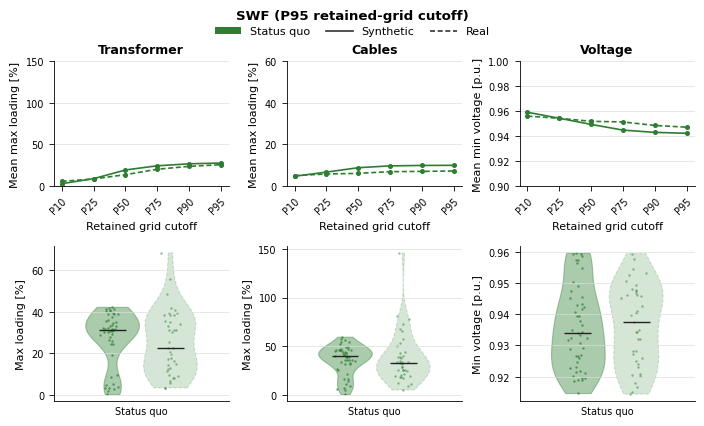

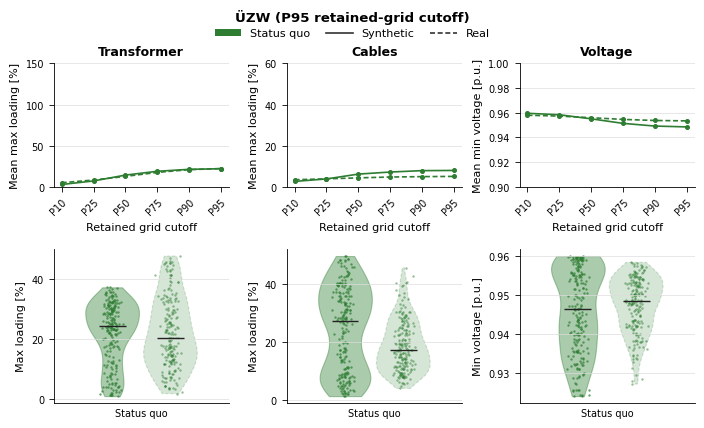

In [7]:
for provider in context["providers"]:
    label = PROVIDER_LABELS[provider]
    fig = plot_powerflow_asset_cutoff_overview_static(
        profile[profile["provider"] == label],
        group_col="comparison_stage",
        source_col="network",
        color_map=CASE_COLORS,
        group_labels=CASE_DISPLAY,
        asset_cutoff_percentile=0.95,
        asset_percentiles=(0.10, 0.25, 0.50, 0.75, 0.90, 1.0),
        filter_scope="grid",
        curve_y_axis_limits=CURVE_Y_LIMITS,
        title=label,
        save_path=FIGURE_DIR / f"asset-percentiles-{provider}",
    )
    plt.show()

## Cable maximum loading ECDF

In [8]:
plot_cable_max_loading_ecdf(
    profile,
    group_col="network",
    color_map=NETWORK_COLORS,
    title="Status-quo cable maximum loading",
    show=False,
)